In [25]:
import numpy as np  # Math helper for numbers and arrays
import pandas as pd  # Tool to store and work with tables
import matplotlib.pyplot as plt  # Basic plotting tool
import seaborn as sns  # Nicer-looking plots
from sklearn.model_selection import train_test_split  # Split data into training and testing parts
from sklearn.linear_model import LinearRegression  # Simple line-fitting model
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error  # Ways to score the model

import warnings  # Lets us control warning messages
warnings.filterwarnings('ignore')  # Hide harmless warnings to keep output clean

print("Libraries loaded.")  # Let the user know imports finished

Libraries loaded.


In [26]:
np.random.seed(42)  # Make random numbers repeat the same way every run

temperature = np.random.uniform(low=20, high=40, size=100)  # Create 100 fake temperatures between 20 and 40

sales = (temperature * 12.5) + np.random.normal(loc=0, scale=25, size=100) + 50  # Make sales mostly follow temperature, plus some noise and a base level

df = pd.DataFrame({'Temperature_C': temperature, 'Sales_Units': sales})  # Put the numbers into a table with two columns

# df.head()  # (Optional) Show just the first few rows of the table
print(df)  # Show the whole table so we can see the data we made

    Temperature_C  Sales_Units
0       27.490802   395.811206
1       39.014286   530.203393
2       34.639879   485.292505
3       31.973170   399.975398
4       23.120373   333.512863
..            ...          ...
95      29.875912   403.053642
96      30.454657   428.755665
97      28.550820   415.414054
98      20.508383   313.272052
99      22.157829   347.652438

[100 rows x 2 columns]


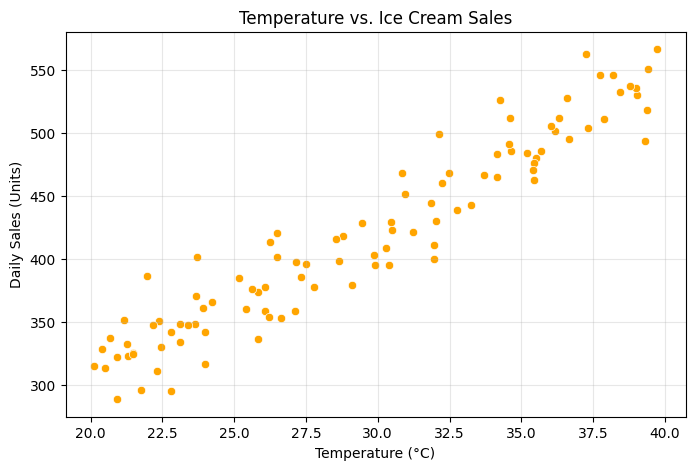

In [27]:
plt.figure(figsize=(8, 5))  # Set the picture size so it is easy to read
sns.scatterplot(x='Temperature_C', y='Sales_Units', data=df, color='orange')  # Plot each day as a dot
plt.title('Temperature vs. Ice Cream Sales')  # Name the chart
plt.xlabel('Temperature (°C)')  # Label the bottom axis
plt.ylabel('Daily Sales (Units)')  # Label the side axis
plt.grid(True, alpha=0.3)  # Add light grid lines to guide the eyes
plt.show()  # Draw the chart on the screen

In [28]:
X = df[['Temperature_C']]  # Pick the temperature column as the input feature (needs 2D shape)
y = df['Sales_Units']       # Pick the sales column as the answer we want to predict

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)  # Split data into 80% train and 20% test

print(f"Training Data Size: {X_train.shape}")  # Tell us how big the training set is
print(f"Test Data Size: {X_test.shape}")  # Tell us how big the test set is

Training Data Size: (80, 1)
Test Data Size: (20, 1)


In [29]:
model = LinearRegression()  # Create a simple line-fitting model

model.fit(X_train, y_train)  # Teach the model using the training data
 # Sales = b0 + (b1 x Temperature)  # Example of the straight-line formula the model learns
 # Sales = 63.61 + (12 x Temperature)  # Example with made-up numbers plugged in

print("Model training completed.")  # Let us know training finished
print(f"Model intercept (b0): {model.intercept_:.2f}")  # The base sales value when temperature is 0
print(f"Model coefficient (b1): {model.coef_[0]:.2f}")  # How much sales change for each extra degree

Model training completed.
Model intercept (b0): 63.61
Model coefficient (b1): 12.00


In [30]:
y_pred = model.predict(X_test)  # Use the model to guess sales for the test data

comparison = pd.DataFrame({'Actual': y_test.values, 'Predicted': y_pred})  # Show real vs. guessed numbers side by side
print(comparison.head())  # Peek at the first few rows of the comparison

# success metrics
mae = mean_absolute_error(y_test, y_pred)  # Average size of the errors (lower is better)
mse = mean_squared_error(y_test, y_pred)  # Like MAE but squares errors to punish big mistakes
rmse = np.sqrt(mse)  # Square root of MSE so the units match the original data
r2 = r2_score(y_test, y_pred)  # How much of the variation in sales the model explains (closer to 1 is better)

print("\n--- Model Performance ---")  # Header for the scores
print(f"Mean Absolute Error (MAE): {mae:.2f}")  # Average error in sales units
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")  # Bigger errors matter more here
print(f"R-Squared (R2 Score): {r2:.2f}")  # 1.0 means perfect, 0 means no better than guessing the average

       Actual   Predicted
0  332.303428  318.824688
1  511.119946  518.301137
2  462.137425  488.885463
3  442.895885  462.555777
4  384.470794  365.671277

--- Model Performance ---
Mean Absolute Error (MAE): 14.78
Root Mean Squared Error (RMSE): 20.21
R-Squared (R2 Score): 0.93


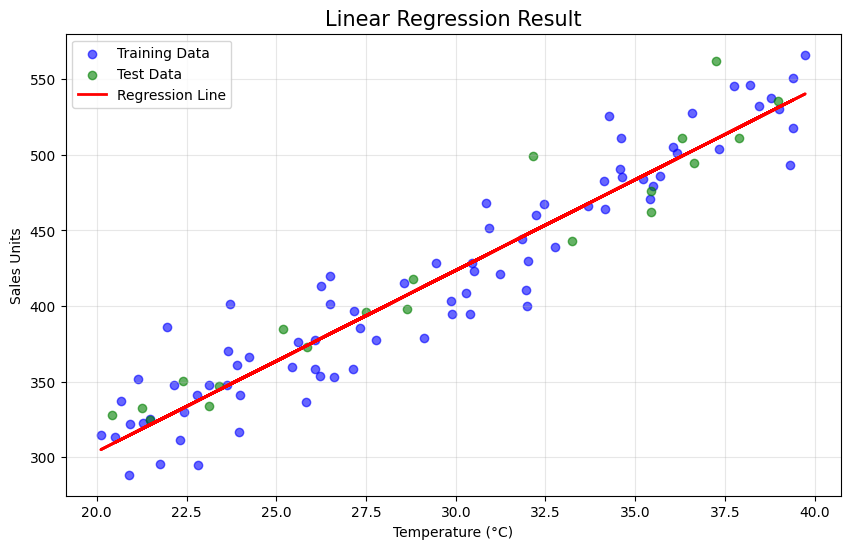

In [31]:
plt.figure(figsize=(10, 6))  # Set a larger canvas so points are easy to see
plt.scatter(X_train, y_train, color='blue', label='Training Data', alpha=0.6)  # Draw training dots
plt.scatter(X_test, y_test, color='green', label='Test Data', alpha=0.6)  # Draw test dots
plt.plot(X_train, model.predict(X_train), color='red', linewidth=2, label='Regression Line')  # Draw the best-fit line

plt.title('Linear Regression Result', fontsize=15)  # Give the chart a title
plt.xlabel('Temperature (°C)')  # Name the x-axis
plt.ylabel('Sales Units')  # Name the y-axis
plt.legend()  # Show which color is which group
plt.grid(True, alpha=0.3)  # Add light grid lines for reading values
plt.show()  # Display the chart

In [32]:
example_temperature = [[30]]  # Example temperature value shaped like the training data
predicted_sales = model.predict(example_temperature)  # Ask the model to guess sales for that temperature

print(f"When the temperature is {example_temperature[0][0]} degrees, the predicted ice cream sales are: {int(predicted_sales[0])} units.")  # Print the prediction in a friendly sentence

When the temperature is 30 degrees, the predicted ice cream sales are: 423 units.
